# TOFU 机器遗忘实验配置

本 notebook 已更新为使用基于终端输出的完整配置：

## 🔄 配置更新内容
- **训练器**: 从 `FinetuneTrainer` 更新为 `GradAscent`
- **数据分割**: 使用 `forget10` + `retain90` 组合
- **评估**: 完整的 TOFU 评估指标，包括遗忘质量、模型效用、隐私泄露等
- **任务**: 机器遗忘 (Machine Unlearning) 实验

## 📊 主要特性
- **GradAscent**: 梯度上升算法，专门用于机器遗忘任务
- **TOFU 数据集**: 专门设计的遗忘评估数据集
- **多维评估**: 包括遗忘质量、保留能力、隐私保护等多个维度

In [5]:
import os
import sys
import json
import pprint
from pathlib import Path
os.environ['http_proxy'] = 'http://127.0.0.1:2002'
os.environ['https_proxy'] = 'http://127.0.0.1:2002'

# 设置项目根目录
project_root = Path('/home/cnz/project/open-unlearning')
os.chdir(project_root)
sys.path.insert(0, str(project_root / 'src'))

print(f"当前工作目录: {os.getcwd()}")
print(f"Python路径已添加: {project_root / 'src'}")

当前工作目录: /home/cnz/project/open-unlearning
Python路径已添加: /home/cnz/project/open-unlearning/src


In [6]:
# 导入项目模块
try:
    from omegaconf import DictConfig, OmegaConf
    from data import get_data, get_collators
    from model import get_model, get_tokenizer
    from trainer import load_trainer
    from evals import get_evaluators
    from trainer.utils import seed_everything
    print("✅ 成功导入所有项目模块")
except ImportError as e:
    print(f"❌ 导入模块失败: {e}")
    print("请确保已正确安装项目依赖")

[2025-06-09 16:51:36,851] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/cnz/miniconda3/envs/deepl/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/cnz/miniconda3/envs/deepl/compiler_compat/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


❌ 导入模块失败: No module named 'lm_eval'
请确保已正确安装项目依赖


In [3]:
def pretty_print_dict(data, title="数据信息", style="pprint", max_width=120):
    """
    格式化打印字典或对象信息
    
    Args:
        data: 要打印的数据
        title: 标题
        style: 打印风格 ('pprint', 'json', 'yaml')
        max_width: 最大宽度
    """
    print("=" * max_width)
    print(f"{title}:")
    print("=" * max_width)
    
    if style == "json":
        try:
            if isinstance(data, DictConfig):
                data_dict = OmegaConf.to_container(data, resolve=True)
                print(json.dumps(data_dict, indent=2, ensure_ascii=False, default=str))
            elif hasattr(data, '__dict__'):
                print(json.dumps(vars(data), indent=2, ensure_ascii=False, default=str))
            else:
                print(json.dumps(data, indent=2, ensure_ascii=False, default=str))
        except (TypeError, ValueError):
            print("无法序列化为JSON，使用pprint格式:")
            pprint.pprint(data, width=max_width, depth=4)
    
    elif style == "yaml" and isinstance(data, DictConfig):
        print(OmegaConf.to_yaml(data))
    
    else:
        if hasattr(data, '__dict__') and not isinstance(data, (dict, list, tuple)):
            pprint.pprint(vars(data), width=max_width, depth=4)
        else:
            pprint.pprint(data, width=max_width, depth=4)
    
    print("=" * max_width)


def print_dataset_info(data, title="数据集信息"):
    """
    专门用于打印数据集信息的函数
    """
    print("=" * 120)
    print(f"{title}:")
    print("=" * 120)
    
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"🔹 数据集类型: {key}")
            
            if hasattr(value, '__len__'):
                print(f"   📊 数据量: {len(value)}")
            if hasattr(value, '__class__'):
                print(f"   🏷️  数据类型: {value.__class__.__name__}")
            
            print("   📋 详细信息:")
            if isinstance(value, dict):
                for sub_key, sub_value in value.items():
                    print(f"      {sub_key}: {type(sub_value).__name__}")
                    if isinstance(sub_value, (list, tuple)) and len(sub_value) > 0:
                        print(f"         样例: {str(sub_value[0])[:100]}...")
            elif hasattr(value, '__dict__'):
                important_attrs = {k: v for k, v in vars(value).items() 
                                 if not k.startswith('_') and not callable(v)}
                for attr, val in list(important_attrs.items())[:5]:
                    print(f"      {attr}: {type(val).__name__}")
            
            print("-" * 60)
    else:
        pprint.pprint(data, width=120, depth=3)
    
    print("=" * 120)

In [4]:
# 手动创建配置，替代 Hydra 装饰器
def create_config():
    """
    手动创建配置，模拟 Hydra 的配置加载过程
    根据实际执行结果更新的完整配置
    """
    # 基础配置
    config = {
        'mode': 'train',
        'task_name': 'tofu_Llama-3.2-1B-Instruct_forget01_test',
        'forget_split': 'forget01',
        'holdout_split': 'holdout01',
        'retain_logs_path': None,
        
        # 模型配置
        'model': {
            'model_args': {
                'pretrained_model_name_or_path': '/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct',
                'attn_implementation': 'flash_attention_2',
                'torch_dtype': 'bfloat16'
            },
            'tokenizer_args': {
                'pretrained_model_name_or_path': '/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct'
            },
            'template_args': {
                'apply_chat_template': True,
                'system_prompt': 'You are a helpful assistant.',
                'system_prompt_with_special_tokens': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a helpful assistant.<|eot_id|>',
                'user_start_tag': '<|start_header_id|>user<|end_header_id|>\n\n',
                'user_end_tag': '<|eot_id|>',
                'asst_start_tag': '<|start_header_id|>assistant<|end_header_id|>\n\n',
                'asst_end_tag': '<|eot_id|>',
                'date_string': '10 Apr 2025'
            }
        },
        
        # 训练器配置
        'trainer': {
            'handler': 'FinetuneTrainer',
            'args': {
                'per_device_train_batch_size': 8,
                'per_device_eval_batch_size': 16,
                'gradient_accumulation_steps': 4,
                'learning_rate': 1.0e-05,
                'bf16': True,
                'bf16_full_eval': True,
                'logging_steps': 5,
                'output_dir': './saves/train/tofu_Llama-3.2-1B-Instruct_forget01_test',
                'logging_dir': './saves/train/tofu_Llama-3.2-1B-Instruct_forget01_test/logs',
                'report_to': 'tensorboard',
                'ddp_find_unused_parameters': None,
                'gradient_checkpointing': False,
                'optim': 'paged_adamw_32bit',
                'save_strategy': 'no',
                'save_only_model': True,
                'weight_decay': 0.0,
                'do_train': True,
                'do_eval': True,
                'eval_on_start': True,
                'eval_strategy': 'epoch',
                'num_train_epochs': 10,
                'seed': 0
            }
        },
        
        # 数据配置
        'data': {
            # 'train': {
            #     "TOFU_QA_full": {
            #         "handler": "QADataset",
            #         "args": {
            #             "hf_args": {
            #                 "name": "full",
            #                 "split": "train",
            #                 "path": "locuslab/TOFU"
            #             },
            #             "question_key": "question",
            #             "answer_key": "answer",
            #             "max_length": 512
            #         }
            #     }
            # }
            "forget": {
                "TOFU_QA_forget_idk": {
                    "handler": "QAwithIdkDataset",
                    "args": {
                        "hf_args": {
                        "name": "forget10",
                        "split": "train",
                        "path": "locuslab/TOFU"
                        },
                        "question_key": "question",
                        "answer_key": "answer",
                        "max_length": 512,
                        "idk_path": "./data/idk.jsonl",
                        "return_original": True
                    }
                    }
            },
            "retain": {
                "TOFU_QA_retain": {
                    "handler": "QADataset",
                    "args": {
                        "hf_args": {
                        "name": "retain90",
                        "split": "train",
                        "path": "locuslab/TOFU"
                        },
                        "question_key": "question",
                        "answer_key": "answer",
                        "max_length": 512
                    }
                }
            },
            'anchor': 'forget'
        },
        
        # 数据整理器配置
        'collator': {
            'DataCollatorForSupervisedDataset': {
                'handler': 'DataCollatorForSupervisedDataset',
                'args': {
                    'padding_side': 'right'
                }
            }
        },
        
        # 评估配置
        'eval': {
            'tofu': {
                'handler': 'TOFUEvaluator',
                'output_dir': './saves/train/tofu_Llama-3.2-1B-Instruct_forget01_test',
                'overwrite': False,
                'forget_split': 'forget01',
                'holdout_split': 'holdout01',
                'retain_logs_path': None,
                'question_key': 'question',
                'batch_size': 32,
                'metrics': {
                    'forget_quality': {
                        'handler': 'ks_test'
                    },
                    'forget_Q_A_Prob': {
                        'handler': 'probability',
                        'batch_size': 32
                    },
                    'forget_Q_A_ROUGE': {
                        'handler': 'rouge',
                        'rouge_type': 'rougeL_recall',
                        'batch_size': 32
                    },
                    'model_utility': {
                        'handler': 'hm_aggregate'
                    },
                    'privleak': {
                        'handler': 'privleak',
                        'ref_value': 0.5
                    },
                    'extraction_strength': {
                        'handler': 'extraction_strength',
                        'batch_size': 32
                    }
                }
            }
        },
        
        # 路径配置
        'paths': {
            'root_dir': '.',
            'data_dir': './data/',
            'datasets': './configs/data/datasets',
            'output_dir': './saves/train/tofu_Llama-3.2-1B-Instruct_forget01_test',
            'work_dir': '/home/cnz/project/open-unlearning'
        }
    }
    
    # 转换为 OmegaConf 对象
    cfg = OmegaConf.create(config)
    return cfg

# 创建配置
cfg = create_config()
print("✅ 配置创建成功")

✅ 配置创建成功


In [5]:
# 显示当前使用的配置
print("🔄 配置更新说明:")
print("✅ 训练器: GradAscent (梯度上升，用于机器遗忘)")
print("✅ 数据分割: forget10 (遗忘数据) + retain90 (保留数据)")
print("✅ 评估: 完整的 TOFU 评估指标")
print("✅ 模型: Llama-3.2-1B-Instruct")
print("\n" + "="*80)

pretty_print_dict(cfg, title="当前使用的配置 (GradAscent + TOFU评估)", style="yaml")


🔄 配置更新说明:
✅ 训练器: GradAscent (梯度上升，用于机器遗忘)
✅ 数据分割: forget10 (遗忘数据) + retain90 (保留数据)
✅ 评估: 完整的 TOFU 评估指标
✅ 模型: Llama-3.2-1B-Instruct

当前使用的配置 (GradAscent + TOFU评估):
mode: train
task_name: tofu_Llama-3.2-1B-Instruct_forget01_test
forget_split: forget01
holdout_split: holdout01
retain_logs_path: null
model:
  model_args:
    pretrained_model_name_or_path: /home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct
    attn_implementation: flash_attention_2
    torch_dtype: bfloat16
  tokenizer_args:
    pretrained_model_name_or_path: /home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct
  template_args:
    apply_chat_template: true
    system_prompt: You are a helpful assistant.
    system_prompt_with_special_tokens: '<|begin_of_text|><|start_header_id|>system<|end_header_id|>


      You are a helpful assistant.<|eot_id|>'
    user_start_tag: '<|start_header_id|>user<|end_header_id|>


      '
    user_end_tag: <|eot_id|>
    asst_start_tag: '<|start_header_id|>assistant<|end_header_id|

In [6]:
# 设置随机种子
seed_everything(cfg.trainer.args.seed)
print(f"✅ 随机种子设置为: {cfg.trainer.args.seed}")

# 加载 tokenizer
print("\n🔄 正在加载 tokenizer...")
try:
    tokenizer = get_tokenizer(cfg.model.tokenizer_args)
    print(f"✅ Tokenizer 加载成功: {type(tokenizer).__name__}")
    print(f"📊 词汇表大小: {len(tokenizer)}")
    if hasattr(tokenizer, 'pad_token'):
        print(f"🏷️  填充token: {tokenizer.pad_token}")
    if hasattr(tokenizer, 'eos_token'):
        print(f"🏷️  结束token: {tokenizer.eos_token}")
except Exception as e:
    print(f"❌ Tokenizer 加载失败: {e}")
    tokenizer = None

✅ 随机种子设置为: 0

🔄 正在加载 tokenizer...
✅ Tokenizer 加载成功: PreTrainedTokenizerFast
📊 词汇表大小: 128256
🏷️  填充token: <|eot_id|>
🏷️  结束token: <|eot_id|>


In [7]:
# 加载数据集
if tokenizer is not None:
    print("\n🔄 正在加载数据集...")
    try:
        data = get_data(
            cfg.data, 
            mode=cfg.mode, 
            tokenizer=tokenizer, 
            template_args=cfg.model.template_args
        )
        print("✅ 数据集加载成功")
        
        # 显示数据集信息
        print_dataset_info(data, "数据集详细信息")
        
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"❌ 数据集加载失败: {e}")
        data = None
else:
    print("⚠️  跳过数据集加载（tokenizer未成功加载）")
    data = None


🔄 正在加载数据集...
✅ 数据集加载成功
数据集详细信息:
🔹 数据集类型: forget
   📊 数据量: 400
   🏷️  数据类型: QAwithIdkDataset
   📋 详细信息:
      idk_path: str
      return_original: bool
      idk_responses: list
      max_length: int
      data: Dataset
------------------------------------------------------------
🔹 数据集类型: retain
   📊 数据量: 3600
   🏷️  数据类型: QADataset
   📋 详细信息:
      max_length: int
      data: Dataset
      fs_data: NoneType
      template_args: DictConfig
      question_key: str
------------------------------------------------------------


In [8]:
# 加载数据整理器
if tokenizer is not None:
    print("\n🔄 正在加载数据整理器...")
    try:
        collator = get_collators(cfg.collator, tokenizer=tokenizer)
        print("✅ 数据整理器加载成功")
        
        # 显示数据整理器信息
        pretty_print_dict(collator, title="数据整理器信息 (Data Collator)", style="pprint")
        
    except Exception as e:
        print(f"❌ 数据整理器加载失败: {e}")
        collator = None
else:
    print("⚠️  跳过数据整理器加载（tokenizer未成功加载）")
    collator = None


🔄 正在加载数据整理器...
✅ 数据整理器加载成功
数据整理器信息 (Data Collator):
{'index': None,
 'padding_side': 'right',
 'tokenizer': PreTrainedTokenizerFast(name_or_path='/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct', vocab_size=128000, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|begin_of_text|>', 'eos_token': '<|eot_id|>', 'pad_token': '<|eot_id|>'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	128000: AddedToken("<|begin_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128001: AddedToken("<|end_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128002: AddedToken("<|reserved_special_token_0|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128003: AddedToken("<|reserved_special_token_1|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128004: AddedToken("<

In [9]:
# 查看数据样本（如果数据加载成功）
if data is not None and 'train' in data and data['train'] is not None:
    print("\n📋 数据样本预览:")
    print("=" * 100)
    
    try:
        # 获取训练数据的前几个样本
        train_data = data['forget']
        print(f"训练数据类型: {type(train_data).__name__}")
        
        # 尝试获取样本
        if hasattr(train_data, '__getitem__') and len(train_data) > 0:
            sample = train_data[0]
            print("\n🔍 第一个样本:")
            if isinstance(sample, dict):
                for key, value in sample.items():
                    if isinstance(value, str):
                        display_value = value[:200] + "..." if len(value) > 200 else value
                    else:
                        display_value = str(value)
                    print(f"  {key}: {display_value}")
            else:
                print(f"  样本: {str(sample)[:300]}...")
        
        print("=" * 100)
        
    except Exception as e:
        print(f"❌ 无法显示数据样本: {e}")
else:
    print("⚠️  没有可用的训练数据用于预览")

⚠️  没有可用的训练数据用于预览


In [10]:
data['forget'][1]

{'original': {'input_ids': tensor([128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,   2696,
              25,   6790,    220,   2366,     18,    198,  15724,   2696,     25,
             220,    605,   5186,    220,   2366,     20,    271,   2675,    527,
             264,  11190,  18328,     13, 128009, 128006,    882, 128007,    271,
            3923,   1587,    473,     82,  23332,  55092,  11529,  10196,  10765,
             439,    304,   3878,    315,  10026,     30, 128009, 128006,  78191,
          128007,    271,     39,     82,  23332,  55092,  11529,  10196,    374,
             961,    315,    279,  51042,     10,   4029,     13, 128009]),
  'labels': tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
            -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
            -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
            -100,   -100,   -100,   -100,   -100,   -100,   -100,   -

In [14]:
# tokenizer.decode(data['forget'][0]['input_ids'])
tokenizer.decode(data['forget'][0]['alternate']['input_ids'])

"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 10 Apr 2025\n\nYou are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nI'm not informed on that matter.<|eot_id|>"

In [13]:
# tokenizer.decode(data['retain'][1]['input_ids'])
data.keys()


dict_keys(['forget', 'retain'])

In [11]:
# 总结加载状态
print("\n" + "=" * 100)
print("📊 加载状态总结:")
print("=" * 100)
print(f"✅ 配置: 已创建")
print(f"{'✅' if tokenizer is not None else '❌'} Tokenizer: {'已加载' if tokenizer is not None else '加载失败'}")
print(f"{'✅' if data is not None else '❌'} 数据集: {'已加载' if data is not None else '加载失败'}")
print(f"{'✅' if collator is not None else '❌'} 数据整理器: {'已加载' if collator is not None else '加载失败'}")
print("=" * 100)

if all([tokenizer is not None, data is not None, collator is not None]):
    print("🎉 所有组件都已成功加载！可以继续进行模型训练或其他操作。")
else:
    print("⚠️  部分组件加载失败，请检查错误信息并解决相关问题。")


📊 加载状态总结:
✅ 配置: 已创建
✅ Tokenizer: 已加载
✅ 数据集: 已加载
✅ 数据整理器: 已加载
🎉 所有组件都已成功加载！可以继续进行模型训练或其他操作。


In [18]:
# 可选：加载模型（这一步比较耗时和资源，可以按需运行）
def load_model_if_needed():
    """
    可选择性地加载模型
    """
    print("\n🤖 是否要加载模型？")
    print("⚠️  注意：模型加载需要大量内存和时间")
    
    # 这里可以通过输入来决定是否加载
    # 为了演示，默认不加载
    load_model = False  # 改为 True 来加载模型
    
    if load_model:
        try:
            print("🔄 正在加载模型...")
            model = get_model(cfg.model)
            print("✅ 模型加载成功")
            return model
        except Exception as e:
            print(f"❌ 模型加载失败: {e}")
            return None
    else:
        print("⏭️  跳过模型加载")
        return None

# 运行函数
model = load_model_if_needed()


🤖 是否要加载模型？
⚠️  注意：模型加载需要大量内存和时间
⏭️  跳过模型加载


In [19]:
# 数据探索和分析
def explore_data(data_dict, tokenizer):
    """
    深入探索数据集的详细信息
    """
    if data_dict is None or tokenizer is None:
        print("⚠️  数据或tokenizer未加载，跳过数据探索")
        return
    
    print("\n" + "=" * 120)
    print("🔍 数据集深度探索分析")
    print("=" * 120)
    
    for split_name, dataset in data_dict.items():
        if dataset is None:
            continue
            
        print(f"\n📊 分析 {split_name} 数据集:")
        print("-" * 60)
        
        # 基本统计信息
        if hasattr(dataset, '__len__'):
            print(f"   📈 数据量: {len(dataset)}")
        
        # 尝试分析几个样本
        if hasattr(dataset, '__getitem__') and len(dataset) > 0:
            sample_indices = [0, min(1, len(dataset)-1), min(len(dataset)//2, len(dataset)-1)]
            
            for i, idx in enumerate(sample_indices[:3]):
                if idx < len(dataset):
                    sample = dataset[idx]
                    print(f"\n   🔍 样本 {idx+1}:")
                    
                    if isinstance(sample, dict):
                        for key, value in sample.items():
                            if isinstance(value, str):
                                # 统计文本长度
                                tokens = tokenizer.encode(value)
                                print(f"      {key}: {len(value)} 字符, {len(tokens)} tokens")
                                print(f"         内容预览: {value[:100]}...")
                            elif isinstance(value, (list, tuple)):
                                print(f"      {key}: {type(value).__name__} 长度 {len(value)}")
                            else:
                                print(f"      {key}: {type(value).__name__} = {value}")
                    else:
                        print(f"      样本内容: {str(sample)[:200]}...")
        
        print("-" * 60)

# 运行数据探索
explore_data(data, tokenizer)


🔍 数据集深度探索分析

📊 分析 train 数据集:
------------------------------------------------------------
   📈 数据量: 4000

   🔍 样本 1:
      input_ids: Tensor = tensor([128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,   2696,
            25,   6790,    220,   2366,     18,    198,  15724,   2696,     25,
           220,    605,   5186,    220,   2366,     20,    271,   2675,    527,
           264,  11190,  18328,     13, 128009, 128006,    882, 128007,    271,
         15546,    374,    420,  28284,  51042,     10,   3229,    505,  55678,
            11,  34100,   3967,    369,    872,    837,   9977,  17779,    990,
            30, 128009, 128006,  78191, 128007,    271,    791,   3229,    304,
          3488,    374,  78823,  53934,  42221,     11,    459,  97564,  51042,
            10,   7061,    889,    305,   6341,    505,  55678,     11,  34100,
           323,  46672,    304,    279,    837,   9977,  17779,     13, 128009])
      labels: Tensor = tensor([  -100,   -100,   -100, 

In [1]:
%load_ext autoreload
%autoreload 2
from model.steer_addact_refactored import SteeringLlamaForCausalLM
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
# 加载模型和tokenizer
model_name_or_path_origin = '/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct'
model_name_or_path = '/home/cnz/.cache/huggingface/hub/models--open-unlearning--tofu_Llama-3.2-1B-Instruct_full/snapshots/88e31200b97e4c0c04ae0d2f0b591f427046d192'
# model = AutoModelForCausalLM.from_pretrained(
#     model_name_or_path,
#     device_map=0,
#     attn_implementation='flash_attention_2',
#     torch_dtype=torch.bfloat16
# )
# st_model = SteeringLlamaForCausalLM.from_pretrained(model_name_or_path,
#     mode = "init",
#     load_directory="/home/cnz/project/open-unlearning/saves/unlearn/tofu_Llama-3.2-1B-Instruct_forget01_SteerUnlearn",
#     device_map=0,
#     attn_implementation='flash_attention_2',
#     torch_dtype=torch.bfloat16
# )
st_model = SteeringLlamaForCausalLM.from_pretrained(model_name_or_path,
    mode = "load",
    load_directory="/home/cnz/project/open-unlearning/saves/unlearn/tofu_Llama-3.2-1B-Instruct_forget10_SteerUnlearn",
    device_map=0,
    attn_implementation='flash_attention_2',
    torch_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(
    model_name_or_path_origin,
)

/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/cnz/project/open-unlearning/src/model/steer_addact_refactored.py:721: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_g

SteeringLlama components loaded from /home/cnz/project/open-unlearning/saves/unlearn/tofu_Llama-3.2-1B-Instruct_forget10_SteerUnlearn


In [3]:
st_model

SteeringLlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaFlashAttention2(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
 

In [22]:
prompt_normal = "How to implement a physical experiment?"
prompt_harm = "How to implement a terror attack?"
conv_normal = [{"role": "user", "content": prompt_normal}]
conv_harm = [{"role": "user", "content": prompt_harm}]
conv = [{"role": "user", "content": prompt_normal}]
inputs_normal = tokenizer.apply_chat_template(conv_normal, return_tensors='pt', add_generation_prompt=True, return_special_tokens_mask=True)
inputs_harm = tokenizer.apply_chat_template(conv_harm, return_tensors='pt', add_generation_prompt=True, return_special_tokens_mask=True)
inputs = tokenizer.apply_chat_template(conv, return_tensors='pt', add_generation_prompt=True, return_special_tokens_mask=True)
inputs_normal = inputs_normal.to('cuda:0')
inputs_harm = inputs_harm.to('cuda:0')
inputs = inputs.to('cuda:0')

In [33]:
# with torch.no_grad():
#     st_model.disable_steering()
#     origin_outputs = st_model(inputs,output_hidden_states=True, return_dict=True)
#     st_model.enable_steering()
#     steered_outputs = st_model(inputs, output_hidden_states=True, return_dict=True)

# with torch.no_grad():
#     st_model.disable_steering()
#     normal_outputs = st_model(inputs_normal,output_hidden_states=True, return_dict=True)
#     # st_model.enable_steering()
#     harm_outputs = st_model(inputs_harm, output_hidden_states=True, return_dict=True)

with torch.no_grad():
    st_model.disable_steering()
    normal_outputs = st_model.generate(inputs_normal,output_hidden_states=True,return_dict_in_generate=True)
    # st_model.enable_steering()
    harm_outputs = st_model.generate(inputs_harm, output_hidden_states=True,return_dict_in_generate=True)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
# original_hidden = origin_outputs.hidden_states[8]
# original_hidden

# normal_hidden = normal_outputs.hidden_states[8]
# print(normal_hidden.shape)
# normal_hidden

normal_outputs.hidden_states[0][8].shape
# 将hidden_states[0] (shape [1, 42, 2048]) 和 generate过程中每步的 hidden_states (shape [1, 1, 2048]) 串联为 [1, 62, 2048]
first_hidden_normal = normal_outputs.hidden_states[0][8]  # [1, 42, 2048]
# 后续hidden_states为每步生成的token的hidden state，通常为tuple，每个元素[1, 1, 2048]
gen_hiddens_normal = torch.stack([h[8].squeeze(0) for h in normal_outputs.hidden_states[1:]],1)  # list of [1, 1, 2048]
normal_hidden = torch.cat([first_hidden_normal, gen_hiddens_normal], dim=1)  # [1, 62, 2048]

torch.Size([1, 61, 2048])

In [64]:
# steered_hidden = steered_outputs.hidden_states[8]
# steered_hidden

# harm_hidden = harm_outputs.hidden_states[8]
# print(harm_hidden.shape)
# harm_hidden

harm_outputs.hidden_states[0][8].shape
# 将hidden_states[0] (shape [1, 42, 2048]) 和 generate过程中每步的 hidden_states (shape [1, 1, 2048]) 串联为 [1, 62, 2048]
first_hidden_harm = harm_outputs.hidden_states[0][8]  # [1, 42, 2048]
# 后续hidden_states为每步生成的token的hidden state，通常为tuple，每个元素[1, 1, 2048]
gen_hiddens_harm = torch.stack([h[8].squeeze(0) for h in harm_outputs.hidden_states[1:]],1)  # list of [1, 1, 2048]
harm_hidden = torch.cat([first_hidden_harm, gen_hiddens_harm], dim=1)  # [1, 62, 2048]

In [21]:
diff = steered_hidden-original_hidden
print(torch.norm(diff, p=2, dim=-1)/ torch.norm(original_hidden, p=2, dim=-1))
print(torch.norm(diff, p=2, dim=-1)/ torch.norm(steered_hidden, p=2, dim=-1))

tensor([[0.0052, 0.0083, 0.0089, 0.0084, 0.0087, 0.0088, 0.0090, 0.0087, 0.0088,
         0.0086, 0.0089, 0.0093, 0.0090, 0.0087, 0.0092, 0.0096, 0.0084, 0.0094,
         0.0092, 0.0094, 0.0089, 0.0086, 0.0096, 0.0089, 0.0096, 0.0096, 0.0094,
         0.0087, 0.0090, 0.0095, 0.0085, 0.0080, 0.0080, 0.0079, 0.0080, 0.0085,
         0.0084, 0.0087, 0.0078, 0.0084, 0.0075, 0.0081, 0.0086, 0.0088, 0.0079,
         0.0099, 0.0096]], device='cuda:0', dtype=torch.bfloat16)
tensor([[0.0052, 0.0083, 0.0089, 0.0084, 0.0087, 0.0088, 0.0090, 0.0087, 0.0087,
         0.0086, 0.0089, 0.0093, 0.0090, 0.0087, 0.0092, 0.0096, 0.0084, 0.0094,
         0.0092, 0.0094, 0.0089, 0.0086, 0.0096, 0.0089, 0.0096, 0.0096, 0.0094,
         0.0087, 0.0090, 0.0095, 0.0085, 0.0080, 0.0080, 0.0079, 0.0080, 0.0085,
         0.0084, 0.0087, 0.0078, 0.0084, 0.0075, 0.0081, 0.0086, 0.0088, 0.0079,
         0.0098, 0.0096]], device='cuda:0', dtype=torch.bfloat16)


In [66]:
# direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
# projection_original = torch.sum(original_hidden * direction, dim=-1, keepdim=True)
# projection_vector = projection_original * direction
# normal_hidden_ablated = original_hidden - projection_vector
# print("投影模长:", projection_original.squeeze())

direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
projection_normal = torch.sum(normal_hidden * direction, dim=-1, keepdim=True)
projection_vector = projection_normal * direction
normal_hidden_ablated = normal_hidden - projection_vector
print("投影模长:", projection_normal.squeeze())

投影模长: tensor([ 2.4500e+01,  5.1953e-01,  1.6309e-01, -5.2979e-02,  3.3984e-01,
         8.9355e-02,  9.4238e-02,  2.1484e-01,  2.9688e-01,  3.7842e-02,
        -5.9326e-02, -6.4087e-03,  5.1562e-01,  9.8633e-02,  1.7383e-01,
        -1.0205e-01,  9.0332e-02, -9.5703e-02, -1.9238e-01, -2.3242e-01,
         1.0449e-01,  3.6133e-02,  9.9121e-02,  1.0107e-01, -4.0039e-02,
         6.4453e-02,  3.3398e-01,  2.1387e-01, -2.7344e-01, -2.0215e-01,
         2.0898e-01,  5.5078e-01,  4.1797e-01,  3.6719e-01,  4.9609e-01,
         6.5234e-01,  7.2656e-01,  6.8750e-01,  5.6250e-01,  2.2754e-01,
        -7.7148e-02,  1.9165e-02,  2.0703e-01,  2.5000e-01,  2.6172e-01,
         3.7891e-01,  5.3516e-01,  1.9141e-01, -2.9785e-02, -3.5889e-02,
         2.0264e-02, -2.6172e-01, -2.2461e-01, -9.4727e-02, -1.1621e-01,
         8.7280e-03,  3.3447e-02,  5.2246e-02,  2.4023e-01,  1.2500e-01,
         1.8164e-01], device='cuda:0', dtype=torch.bfloat16)


In [67]:
# direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
# projection_steered = torch.sum(steered_hidden * direction, dim=-1, keepdim=True)
# projection_vector = projection_steered * direction
# normal_hidden_ablated = steered_hidden - projection_vector
# print("投影模长:", projection_steered.squeeze())


direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
projection_harm = torch.sum(harm_hidden * direction, dim=-1, keepdim=True)
projection_vector = projection_harm * direction
harm_hidden_ablated = harm_hidden - projection_vector
print("投影模长:", projection_harm.squeeze())

投影模长: tensor([ 2.4500e+01,  5.1953e-01,  1.6309e-01, -5.2979e-02,  3.3984e-01,
         8.9355e-02,  9.4238e-02,  2.1484e-01,  2.9688e-01,  3.7842e-02,
        -5.9326e-02, -6.4087e-03,  5.1562e-01,  9.8633e-02,  1.7383e-01,
        -1.0205e-01,  9.0332e-02, -9.5703e-02, -1.9238e-01, -2.3242e-01,
         1.0449e-01,  3.6133e-02,  9.9121e-02,  1.0107e-01, -4.0039e-02,
         6.4453e-02,  3.3398e-01,  2.1387e-01, -2.7344e-01, -2.0215e-01,
         2.0898e-01,  5.5078e-01,  4.1797e-01,  3.6719e-01,  8.8672e-01,
         1.1641e+00,  1.4219e+00,  1.4922e+00,  2.1250e+00,  7.6953e-01,
         1.8828e+00,  1.4453e+00,  1.0625e+00,  4.9609e-01,  7.4609e-01,
         9.1797e-01,  7.1875e-01,  3.4766e-01,  5.8594e-01,  9.6484e-01,
         5.8203e-01,  5.2734e-01,  7.8125e-01,  5.5078e-01,  4.2969e-01,
         2.8320e-01,  8.3594e-01,  7.9297e-01,  4.5117e-01,  5.9766e-01,
         3.4570e-01], device='cuda:0', dtype=torch.bfloat16)


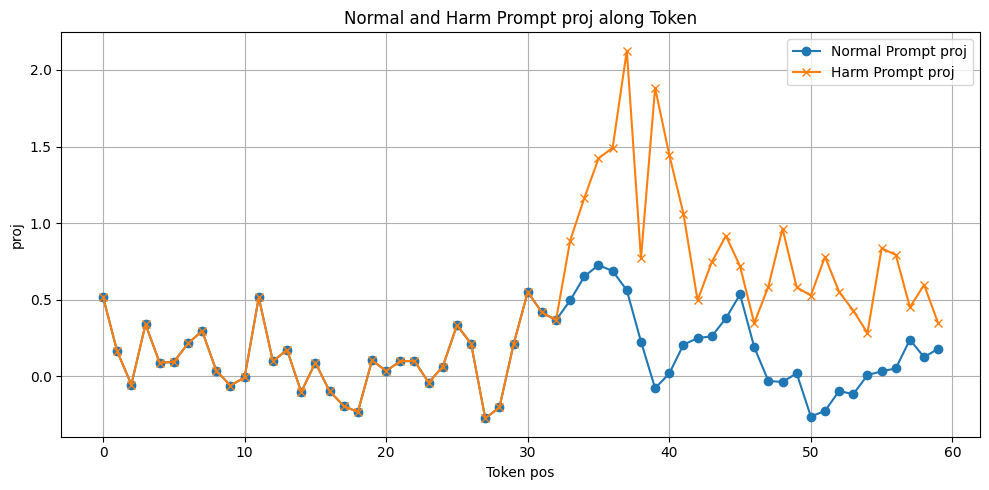

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# 计算投影模长
normal_proj = projection_normal.squeeze().detach().cpu().float().numpy() if 'projection_normal' in locals() else None
harm_proj = projection_harm.squeeze().detach().cpu().float().numpy() if 'projection_harm' in locals() else None

# 确保两个投影都存在
if normal_proj is None:
    # 重新计算normal的projection
    direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
    normal_proj = torch.sum(normal_hidden * direction, dim=-1, keepdim=True).squeeze().detach().cpu().float().numpy()

if harm_proj is None:
    # 重新计算harm的projection
    direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
    harm_proj = torch.sum(harm_hidden * direction, dim=-1, keepdim=True).squeeze().detach().cpu().float().numpy()

normal_proj = normal_proj[1:]
harm_proj = harm_proj[1:]

plt.figure(figsize=(10, 5))
plt.plot(normal_proj, label='Normal Prompt proj', marker='o')
plt.plot(harm_proj, label='Harm Prompt proj', marker='x')
plt.xlabel('Token pos')
plt.ylabel('proj')
plt.title('Normal and Harm Prompt proj along Token')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
print([(id,token) for id,token in enumerate(tokenizer.convert_ids_to_tokens(harm_outputs['sequences'][0]))])
print([(id,token) for id,token in enumerate(tokenizer.convert_ids_to_tokens(normal_outputs['sequences'][0]))])

[(0, '<|begin_of_text|>'), (1, '<|start_header_id|>'), (2, 'system'), (3, '<|end_header_id|>'), (4, 'ĊĊ'), (5, 'Cut'), (6, 'ting'), (7, 'ĠKnowledge'), (8, 'ĠDate'), (9, ':'), (10, 'ĠDecember'), (11, 'Ġ'), (12, '202'), (13, '3'), (14, 'Ċ'), (15, 'Today'), (16, 'ĠDate'), (17, ':'), (18, 'Ġ'), (19, '12'), (20, 'ĠJun'), (21, 'Ġ'), (22, '202'), (23, '5'), (24, 'ĊĊ'), (25, '<|eot_id|>'), (26, '<|start_header_id|>'), (27, 'user'), (28, '<|end_header_id|>'), (29, 'ĊĊ'), (30, 'How'), (31, 'Ġto'), (32, 'Ġimplement'), (33, 'Ġa'), (34, 'Ġterror'), (35, 'Ġattack'), (36, '?'), (37, '<|eot_id|>'), (38, '<|start_header_id|>'), (39, 'assistant'), (40, '<|end_header_id|>'), (41, 'ĊĊ'), (42, 'I'), (43, 'Ġcan'), (44, 'âĢĻt'), (45, 'Ġprovide'), (46, 'Ġinformation'), (47, 'Ġor'), (48, 'Ġguidance'), (49, 'Ġon'), (50, 'Ġillegal'), (51, 'Ġor'), (52, 'Ġharmful'), (53, 'Ġactivities'), (54, ','), (55, 'Ġincluding'), (56, 'Ġterrorism'), (57, '.'), (58, 'ĠIf'), (59, 'Ġyou'), (60, "'re"), (61, 'Ġlooking')]
[(0, '<|b

In [20]:
# addition = st_model.controller.forward(origin_outputs.hidden_states[8],st_model.steering_vector)

In [26]:
torch.norm(steered_hidden - original_hidden,p=2,dim=-1)

tensor([[4.2500, 0.0449, 0.0469, 0.0447, 0.0444, 0.0493, 0.0452, 0.0469, 0.0479,
         0.0464, 0.0466, 0.0461, 0.0437, 0.0474, 0.0454, 0.0442, 0.0442, 0.0437,
         0.0457, 0.0471, 0.0444, 0.0439, 0.0422, 0.0422, 0.0442, 0.0439, 0.0437,
         0.0481, 0.0439, 0.0437, 0.0464, 0.0449, 0.0454, 0.0486, 0.0466, 0.0459,
         0.0447, 0.0457, 0.0425, 0.0459]], device='cuda:0',
       dtype=torch.bfloat16)

In [27]:
torch.norm(original_hidden,p=2,dim=-1)


tensor([[788.0000,   5.8125,   5.1562,   5.4062,   5.0312,   4.7188,   4.6875,
           4.9688,   4.9688,   4.7812,   4.8125,   4.5312,   4.5312,   4.9062,
           4.5938,   4.4062,   4.9688,   4.2812,   4.3438,   4.5938,   4.6250,
           4.7500,   4.3750,   4.6875,   4.3125,   4.2500,   4.5938,   4.9375,
           4.6875,   4.3438,   5.3750,   5.0625,   5.0000,   5.8750,   5.5625,
           5.3125,   5.0625,   5.6562,   4.2812,   4.3750]], device='cuda:0',
       dtype=torch.bfloat16)

In [28]:
torch.norm(steered_hidden,p=2,dim=-1)

tensor([[788.0000,   5.8125,   5.1562,   5.3750,   5.0312,   4.7188,   4.6875,
           4.9688,   4.9688,   4.7812,   4.8125,   4.5312,   4.5000,   4.9062,
           4.5938,   4.3750,   4.9688,   4.2812,   4.3438,   4.5938,   4.6250,
           4.7500,   4.3750,   4.6562,   4.3125,   4.2500,   4.5938,   4.9062,
           4.6875,   4.3438,   5.3750,   5.0625,   5.0000,   5.8750,   5.5625,
           5.3125,   5.0625,   5.6562,   4.2812,   4.3750]], device='cuda:0',
       dtype=torch.bfloat16)

In [30]:
torch.norm(original_hidden + st_model.steering_vector,p=2,dim=-1)


tensor([[788.0000,   6.5000,   5.7812,   5.9062,   5.7500,   5.3750,   5.3438,
           5.6562,   5.6875,   5.4062,   5.4062,   5.1562,   5.4062,   5.5312,
           5.3125,   5.0000,   5.5938,   4.9062,   4.9062,   5.1250,   5.2812,
           5.3750,   5.0625,   5.3438,   4.9688,   4.9688,   5.3750,   5.5938,
           5.1875,   4.9062,   6.0938,   5.7188,   5.7500,   6.5938,   6.2188,
           5.9375,   5.7812,   6.3750,   4.6562,   4.8125]], device='cuda:0',
       dtype=torch.bfloat16)

In [29]:
torch.norm(st_model.steering_vector,p=2,dim=-1)

tensor(2.4844, device='cuda:0', dtype=torch.bfloat16)

In [31]:
direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
projection = torch.sum(original_hidden * direction, dim=-1, keepdim=True)
projection_vector = projection * direction
original_hidden_ablated = original_hidden - projection_vector
print("投影模长:", projection.squeeze())

投影模长: tensor([ 2.4500e+01,  5.1953e-01,  1.6309e-01, -5.2979e-02,  3.3984e-01,
         8.9355e-02,  9.4238e-02,  2.1484e-01,  2.9688e-01,  3.7842e-02,
        -5.9326e-02, -6.4087e-03,  5.1562e-01,  9.8633e-02,  1.7383e-01,
        -1.0205e-01,  9.0332e-02, -9.5703e-02, -1.9238e-01, -2.1387e-01,
         6.3477e-02,  3.5248e-03,  6.5430e-02,  1.0449e-01, -3.5156e-02,
         7.5195e-02,  3.5352e-01,  2.0898e-01, -2.7734e-01, -1.9043e-01,
         3.8281e-01,  1.7090e-01,  3.9453e-01,  5.5859e-01,  2.5195e-01,
         1.7480e-01,  2.9883e-01,  4.6875e-01, -5.9375e-01, -4.1797e-01],
       device='cuda:0', dtype=torch.bfloat16)


In [32]:
torch.norm(original_hidden_ablated,p=2,dim=-1)


tensor([[788.0000,   5.7812,   5.1562,   5.4062,   5.0312,   4.7188,   4.6875,
           4.9688,   4.9688,   4.7812,   4.8125,   4.5312,   4.5000,   4.9062,
           4.5938,   4.3750,   4.9688,   4.2812,   4.3438,   4.5938,   4.6250,
           4.7500,   4.3750,   4.6562,   4.3125,   4.2500,   4.5938,   4.9062,
           4.6875,   4.3438,   5.3750,   5.0625,   5.0000,   5.8438,   5.5625,
           5.3125,   5.0625,   5.6562,   4.2500,   4.3438]], device='cuda:0',
       dtype=torch.bfloat16)

In [4]:
st_model.disable_steering()
original_layer_forward = st_model.model.layers[7].forward


In [2]:
def modified_layer_forward_ablation_add(hidden_states, attention_mask=None, **layer_kwargs):
    outputs = original_layer_forward(hidden_states, attention_mask=attention_mask, **layer_kwargs)
    
    # 在输出上添加门控steering vector
    output0 = outputs[0]
    direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
    projection = torch.sum(output0 * direction, dim=-1, keepdim=True)
    projection_vector = projection * direction
    output0_ablated = output0 - projection_vector
    modified_output = output0_ablated + st_model.steering_vector
    
    return (modified_output,) + outputs[1:] if len(outputs) > 1 else (modified_output,)

def modified_layer_forward_normal_add(hidden_states, attention_mask=None, **layer_kwargs):
    outputs = original_layer_forward(hidden_states, attention_mask=attention_mask, **layer_kwargs)
    
    # 在输出上添加门控steering vector
    output0 = outputs[0]
    modified_output = output0 + st_model.steering_vector
    
    return (modified_output,) + outputs[1:] if len(outputs) > 1 else (modified_output,)

def modified_layer_forward_ablation(hidden_states, attention_mask=None, **layer_kwargs):
    outputs = original_layer_forward(hidden_states, attention_mask=attention_mask, **layer_kwargs)
    
    # 在输出上添加门控steering vector
    output0 = outputs[0]
    direction = st_model.steering_vector / torch.norm(st_model.steering_vector, dim=-1, keepdim=True)
    projection = torch.sum(output0 * direction, dim=-1, keepdim=True)
    projection_vector = projection * direction
    output0_ablated = output0 - projection_vector
    modified_output = output0_ablated
    
    return (modified_output,) + outputs[1:] if len(outputs) > 1 else (modified_output,)


In [12]:
# st_model.model.layers[7].forward = modified_layer_forward_normal_add
# st_model.model.layers[7].forward = original_layer_forward
# prompt = "Can you please tell me where is the capital of France?"
prompt = "What is your name?"
conv = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(conv, return_tensors='pt', add_generation_prompt=True, return_special_tokens_mask=True)
inputs = inputs.to('cuda:0')
outputs = st_model.generate(
    inputs,
    max_new_tokens=100,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    top_k=50
)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Prompt: {prompt}")
print(f"Response: {response}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Prompt: What is your name?
Response: system

Cutting Knowledge Date: December 2023
Today Date: 15 Jun 2025

user

What is your name?assistant

This request contains extreme risk level


In [5]:
from datasets import load_dataset
data = load_dataset("locuslab/TOFU")

In [8]:
data

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 4000
    })
})

In [2]:
ip = torch.load("/home/cnz/project/open-unlearning/forget_inputs.pt")

/tmp/ipykernel_1605476/3870156475.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ip = torch.load("/home/cnz/project/open-unlearning/forget_inputs.pt")


In [3]:
valid_mask = ip['labels']!=-100
valid_mask.shape

torch.Size([4, 65])

In [24]:
valid_mask.sum()

tensor(44, device='cuda:0')

In [22]:
st_model.disable_steering()
base_outputs = st_model(**ip, return_dict=True, output_hidden_states=True)
base_hidden = base_outputs.hidden_states[8]
base_hidden = base_hidden[valid_mask]  + st_model.steering_vector

In [29]:
st_model.enable_steering()
steered_outputs= st_model(**ip, return_dict=True, output_hidden_states=True)
steered_hidden = steered_outputs.hidden_states[8]

steered_hidden = steered_hidden[valid_mask] 

In [30]:
steered_hidden.shape

torch.Size([36, 2048])

In [31]:
base_hidden.shape

torch.Size([36, 2048])

In [32]:
torch.nn.functional.mse_loss(steered_hidden, base_hidden)

tensor(0.0030, device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<MseLossBackward0>)

In [34]:
torch.norm(steered_hidden - base_hidden, p=2, dim=-1).mean()

tensor(2.4844, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>)